# SL-MERK Pair Explanation Evaluation

Generate and score SAE-grounded explanations for curated SL-MERK pair-cancer contexts present in the aligned SLformer SAE artifact. Outputs are written as per-target folders under the SAE run `explanations/` directory.


Identify the project root once, then import the batch utilities, SAE helpers, and prompt client.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "SAE").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from SAE.LLM_pipeline.utils.sl_merk_batch import (
    load_sae_artifacts,
    load_sl_merk_ground_truth,
    metric_record,
    prepare_pair_geometry,
    run_final_interpretation,
    run_pair_feature_explanations,
    run_name_from_model_config,
    sl_merk_rows_from_artifact,
    score_final_text,
    strategy_api_call_estimate,
)
from SAE.manifold.utils.projection import encode_dataset
from SAE.SAE_training.model import SAEConfig
from prompt_api.client import AigcBestChatClient

print("Project root:", PROJECT_ROOT)


/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/guoyu/SLformer_interpretation


Configure the SL-MERK batch. The notebook selects SL_MERK rows present in the current SLformer SAE artifact with `target_score >= 0.5`.


In [2]:
RUN_LLM = False
N_TARGETS = None
MIN_TARGET_SCORE = 0.5
RESUME_COMPLETED = True
SLEEP_BETWEEN_FEATURE_CALLS_S = 0.0
EMBEDDING_CONDITIONS = ["actual", "random", "zero"]
CONTROL_SEED = 42

TRAIN_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "SAE_training" / "config" / "train_config.yaml"
MANIFOLD_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "manifold" / "config" / "manifold_config.yaml"
NOTEBOOK_CONFIG_PATH = PROJECT_ROOT / "src" / "SAE" / "LLM_pipeline" / "config" / "explainer_simulator_config.yaml"
SL_MERK_CSV = Path("/data/guoyu/KG-LLM-XSL/data/SL_MERK_groundtruth.csv")
CLIENT_CONFIG = SRC_ROOT / "prompt_api" / "client_config.yaml"
HF_MODEL_ROOT = Path("/data/guoyu/HF-models")

train_cfg = yaml.safe_load(TRAIN_CONFIG_PATH.read_text(encoding="utf-8"))
manifold_cfg = yaml.safe_load(MANIFOLD_CONFIG_PATH.read_text(encoding="utf-8"))
notebook_cfg = yaml.safe_load(NOTEBOOK_CONFIG_PATH.read_text(encoding="utf-8"))

feature_cfg = notebook_cfg["feature_selection"]
evidence_cfg = notebook_cfg["evidence"]
strategy_cfg = notebook_cfg["llm_strategy"]
metric_cfg = {
    "feature_embed_model_path": HF_MODEL_ROOT / "MedCPT-Query-Encoder",
    "feature_tokencls_model_path": HF_MODEL_ROOT / "keyphrase-extraction-kbir-inspec",
    "nli_model_path": HF_MODEL_ROOT / "PubMedBERT-MNLI-MedNLI",
    "evidence_embed_model_path": HF_MODEL_ROOT / "all-MiniLM-L6-v2",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "feature_candidate_backend": "token_cls",
}

run_name = run_name_from_model_config(SAEConfig(**dict(train_cfg["model"])))
SAE_DIR = Path(train_cfg["paths"]["output_base_dir"]) / train_cfg["paths"]["slformer_output_subdir"] / str(train_cfg["scope"]["cancer"]) / run_name
EXPLANATIONS_DIR = SAE_DIR / "explanations"
QUALIFIED_PAIRS_CSV = EXPLANATIONS_DIR / "sl_merk_qualified_pairs.csv"

client = AigcBestChatClient(config_path=CLIENT_CONFIG) if RUN_LLM else None
print("SAE dir:", SAE_DIR)
print("Explanations dir:", EXPLANATIONS_DIR)
print("RUN_LLM:", RUN_LLM)
print("Metric device:", metric_cfg["device"])


SAE dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64
Explanations dir: /home/guoyu/SLformer_interpretation/output/SAE/slformer/mix/hidden4096_gate0.5_orth1_k64/explanations
RUN_LLM: False
Metric device: cuda


Load SL-MERK positives and local curated context rows. The selected target table is the intersection with the current SLformer/SAE artifact.


In [3]:
loaded = load_sae_artifacts(PROJECT_ROOT, TRAIN_CONFIG_PATH, SAE_DIR)
sae = loaded["sae"]
Xn = loaded["Xn"]
y = loaded["y"]
meta = loaded["meta"]

sl_merk = load_sl_merk_ground_truth(SL_MERK_CSV)
artifact_rows = sl_merk_rows_from_artifact(sl_merk, meta, train_cfg["paths"]["groundtruth_dir"])
target_rows = artifact_rows.sort_values("target_score", ascending=False).reset_index(drop=True)
if MIN_TARGET_SCORE is not None:
    target_rows = target_rows.loc[target_rows["target_score"] >= float(MIN_TARGET_SCORE)].reset_index(drop=True)
if N_TARGETS is not None:
    target_rows = target_rows.head(int(N_TARGETS)).reset_index(drop=True)

EXPLANATIONS_DIR.mkdir(parents=True, exist_ok=True)
target_rows.to_csv(QUALIFIED_PAIRS_CSV, index=False)

print("SL_MERK positive rows:", len(sl_merk))
print("SL_MERK rows present in existing aligned artifact:", len(artifact_rows))
print("Unique SL_MERK pairs present in artifact:", artifact_rows["pair_key"].nunique())
print("Qualified target rows:", len(target_rows))
print("MIN_TARGET_SCORE:", MIN_TARGET_SCORE)
print("Unique gene-pair folders:", target_rows["pair_folder"].nunique())
print("All labels are SL:", sorted(sl_merk["label_true"].astype(int).unique()))
display(target_rows[["cancer", "gene_a", "gene_b", "target_idx", "target_score", "fold", "ground_truth_features"]])


SL_MERK positive rows: 112
SL_MERK rows present in existing aligned artifact: 61
Unique SL_MERK pairs present in artifact: 35
Qualified target rows: 6
MIN_TARGET_SCORE: 0.5
Unique gene-pair folders: 6
All labels are SL: [np.int64(1)]


,cancer,gene_a,gene_b,target_idx,target_score,fold,ground_truth_features
0,LUAD,KRAS,PLK1,35023,0.943691,2,[mitotic defects and apoptosis]
1,BRCA,BRCA2,EZH2,43572,0.922231,3,"[DNA damage response, chromatin remodeling]"
2,LUAD,KRAS,PSMB5,46430,0.896639,3,"[proteasome inhibition, accumulation of p53]"
3,LUAD,KRAS,ERH,58027,0.852795,4,[mRNA splicing and mitosis]
4,LUAD,KRAS,GATA2,46230,0.852047,3,"[proteasome production, DNA damage response]"
5,LUAD,KRAS,THOC1,34629,0.564279,2,[required for proliferation]


Load the trained SAE on the configured device and encode the normalized embedding matrix once: $Z=f_{SAE}(X_n)$, with shape `(n_samples, d_hidden)`.


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sae.to(DEVICE)
print("Device:", DEVICE)
print("Xn shape:", Xn.shape)
started = time.monotonic()
Z = encode_dataset(sae, Xn, batch_size=int(notebook_cfg["runtime"]["encode_batch_size"]), device=DEVICE)
print("Z shape:", Z.shape)
print(f"Encoding time: {time.monotonic() - started:.1f}s")


Device: cuda
Xn shape: (58672, 1024)
Z shape: (58672, 4096)
Encoding time: 1.5s


Estimate the LLM work before running. Feature explanations use the configured feature strategy; final pair explanations use the configured final strategy.


In [5]:
if RUN_LLM:
    estimate = strategy_api_call_estimate(
        client,
        str(strategy_cfg["feature_explainer"]),
        str(strategy_cfg["final_interpretation"]),
        int(feature_cfg["n_features_to_explain"]),
    )
    print("Targets:", len(target_rows))
    print("Embedding conditions:", EMBEDDING_CONDITIONS)
    print("API calls per target-condition:", estimate)
    print("Total planned API calls without resume:", estimate["total_calls"] * len(target_rows) * len(EMBEDDING_CONDITIONS))
    print(f"Request timeout: {client.settings.request_timeout_s:.0f}s, retries: {client.settings.request_retries}, retry wait: {client.settings.retry_wait_s:.0f}s")
else:
    print("RUN_LLM=False; completed output folders are loaded without new LLM calls.")


RUN_LLM=False; completed output folders are loaded without new LLM calls.


For each pair-cancer target, compute local SAE geometry, explain the selected dictionary atoms, synthesize the final interpretation, and score only the `## Mechanism` section against SL-MERK ground truth.


In [6]:
template = (PROJECT_ROOT / "src" / "SAE" / "doc" / "prompts" / "final_interpretation_prompt_template.txt").read_text(encoding="utf-8")
projection_cfg = manifold_cfg["projection"]
control_rng = np.random.default_rng(int(CONTROL_SEED))
control_vectors = {
    "random": control_rng.normal(loc=0.0, scale=1.0, size=(len(target_rows), Xn.shape[1])).astype(np.float32),
    "zero": np.zeros((len(target_rows), Xn.shape[1]), dtype=np.float32),
}

def geometry_matrix_for_condition(condition: str, target_pos: int, target_idx: int) -> np.ndarray:
    if condition == "actual":
        return Xn
    matrix = Xn.copy()
    matrix[int(target_idx)] = control_vectors[str(condition)][int(target_pos)]
    return matrix

def output_dir_for_condition(row: pd.Series, condition: str) -> Path:
    pair_dir = f"{row['cancer']}_{row['gene_a']}-{row['gene_b']}"
    if condition == "actual":
        return EXPLANATIONS_DIR / pair_dir
    return EXPLANATIONS_DIR / "embedding_controls" / condition / pair_dir

if not RUN_LLM:
    print("RUN_LLM=False; skipping LLM pair generation and evaluation cell.")
else:
    tasks = [(target_pos, condition) for target_pos in range(len(target_rows)) for condition in EMBEDDING_CONDITIONS]
    for target_pos, condition in tqdm(tasks, desc="LLM pair explanations", unit="run"):
        row = pd.Series(target_rows.iloc[target_pos])
        output_dir = output_dir_for_condition(row, condition)
        output_dir.mkdir(parents=True, exist_ok=True)
        metrics_path = output_dir / "llm_evaluation_metrics.csv"
        if RESUME_COMPLETED and metrics_path.exists():
            print(f"[metrics] {condition} {output_dir.name} reused")
            continue

        Xn_geometry = geometry_matrix_for_condition(condition, target_pos, int(row["target_idx"]))

        geometry = prepare_pair_geometry(
            sae=sae,
            Xn=Xn_geometry,
            y=y,
            meta=meta,
            Z=Z,
            target_idx=int(row["target_idx"]),
            projection_cfg=projection_cfg,
            device=DEVICE,
            feature_topk=int(projection_cfg["topk_features"]),
            sample_scope=str(evidence_cfg["sample_scope"]),
            top_m=int(evidence_cfg["top_m"]),
            explain_exemplars=int(evidence_cfg["explain_exemplars"]),
        )
        feature_rank = geometry["feature_rank"]
        interpretations = run_pair_feature_explanations(
            client=client,
            output_dir=output_dir,
            row=row,
            feature_rank=feature_rank,
            explain_indices=geometry["explain_indices"],
            Z=Z,
            y=y,
            meta=meta,
            feature_strategy=str(strategy_cfg["feature_explainer"]),
            n_features=int(feature_cfg["n_features_to_explain"]),
            sample_scope=str(evidence_cfg["sample_scope"]),
            state=geometry["state"],
            evidence_cfg=evidence_cfg,
            resume_completed=RESUME_COMPLETED,
            sleep_s=SLEEP_BETWEEN_FEATURE_CALLS_S,
        )
        final_result = run_final_interpretation(
            client=client,
            output_dir=output_dir,
            row=row,
            feature_rank=feature_rank,
            interpretations=interpretations,
            template=template,
            final_strategy=str(strategy_cfg["final_interpretation"]),
            resume_completed=RESUME_COMPLETED,
        )
        final_prompt = (output_dir / "final_prompt" / "final_interpretation_prompt.md").read_text(encoding="utf-8")
        metrics = score_final_text(
            row=row,
            final_text=final_result["text"],
            final_prompt=final_prompt,
            metric_cfg=metric_cfg,
        )
        record = metric_record(row, output_dir, metrics, final_result)
        record["embedding_condition"] = condition
        pd.DataFrame([record]).to_csv(output_dir / "llm_evaluation_metrics.csv", index=False)
        display(pd.DataFrame([record]))


RUN_LLM=False; skipping LLM pair generation and evaluation cell.


Summarize the mechanism-section metrics and inspect the generated per-pair folder count.


In [7]:
actual_metric_files = sorted(EXPLANATIONS_DIR.glob("*_*/llm_evaluation_metrics.csv"))
control_metric_files = sorted((EXPLANATIONS_DIR / "embedding_controls").glob("*/*/llm_evaluation_metrics.csv"))

metric_cols = ["feature_recall", "faithfulness_score", "hallucination_score"]
metric_labels = {
    "feature_recall": "Feature recall",
    "faithfulness_score": "Faithfulness",
    "hallucination_score": "Hallucination",
}

def load_metric_file(path: Path, condition: str) -> pd.DataFrame:
    table = pd.read_csv(path)
    if "embedding_condition" not in table.columns:
        table["embedding_condition"] = condition
    table["embedding_condition"] = table["embedding_condition"].fillna(condition).astype(str)
    return table

metric_frames = [load_metric_file(path, "actual") for path in actual_metric_files]
metric_frames.extend(load_metric_file(path, path.parent.parent.name) for path in control_metric_files)
results = pd.concat(metric_frames, ignore_index=True)
summary = results.groupby("embedding_condition")[metric_cols].agg(["mean", "min", "max"]).round(3)
print("Actual metric files:", len(actual_metric_files))
print("Control metric files:", len(control_metric_files))
display(summary)
display(results[["embedding_condition", "pair", "cancer", "target_score", *metric_cols]].sort_values(["embedding_condition", "pair"]))


Actual metric files: 6
Control metric files: 12


feature_recall              faithfulness_score         \
                              mean    min   max               mean    min   
embedding_condition                                                         
actual                       0.798  0.178  0.95              0.848  0.799   
random                       0.769  0.173  0.95              0.904  0.741   
zero                         0.745  0.168  0.95              0.880  0.709   

                           hallucination_score                
                       max                mean    min    max  
embedding_condition                                           
actual               0.914               0.152  0.086  0.201  
random               0.971               0.096  0.029  0.259  
zero                 0.968               0.120  0.032  0.291

,embedding_condition,pair,cancer,target_score,feature_recall,faithfulness_score,hallucination_score
0,actual,BRCA2-EZH2,BRCA,0.922231,0.950000,0.913764,0.086236
1,actual,KRAS-ERH,LUAD,0.852795,0.178375,0.808364,0.191636
2,actual,KRAS-GATA2,LUAD,0.852047,0.868129,0.861754,0.138246
3,actual,KRAS-PLK1,LUAD,0.943691,0.942489,0.860722,0.139278
4,actual,KRAS-PSMB5,LUAD,0.896639,0.899902,0.845537,0.154463
5,actual,KRAS-THOC1,LUAD,0.564279,0.950000,0.798510,0.201490
6,random,BRCA2-EZH2,BRCA,0.922231,0.950000,0.939203,0.060797
7,random,KRAS-ERH,LUAD,0.852795,0.173134,0.970680,0.029320
8,random,KRAS-GATA2,LUAD,0.852047,0.913292,0.912551,0.087449
9,random,KRAS-PLK1,LUAD,0.943691,0.826260,0.888860,0.111140


Plot mechanism-section metrics and SAE geometry-control signals for actual, random, and zero embeddings.

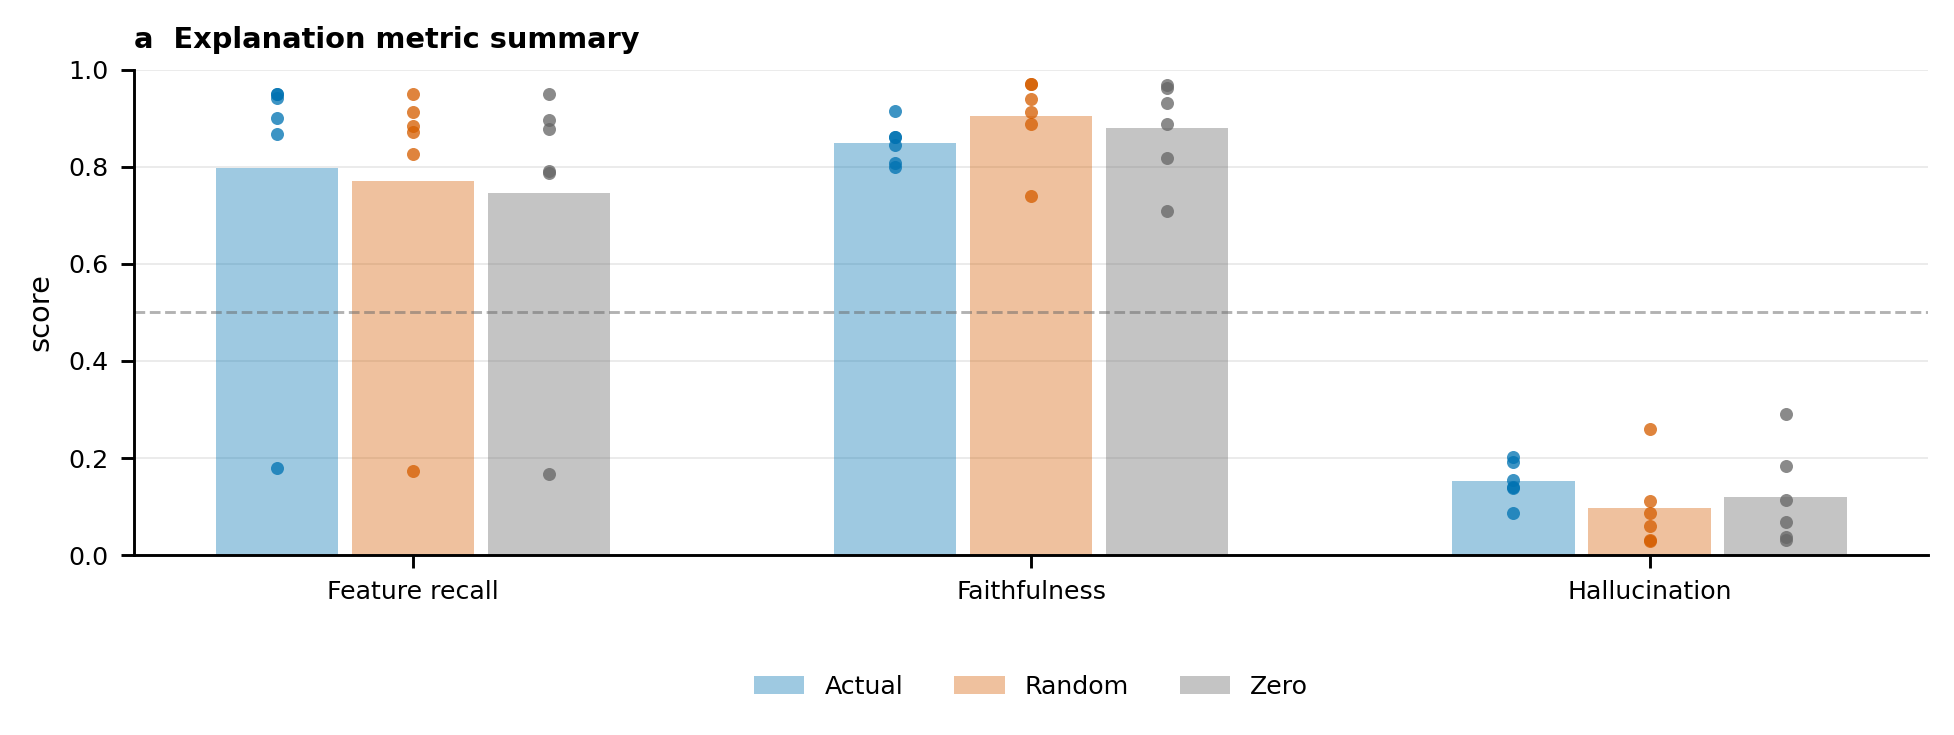

,pair,condition,max_abs_z0,mean_abs_z0,max_abs_jvp,max_abs_delta_z,max_abs_c_star
0,BRCA2-EZH2,actual,7.020288,0.042217,0.191360,0.000191,0.193619
1,KRAS-ERH,actual,11.414111,0.039361,0.124748,0.000126,0.130851
2,KRAS-GATA2,actual,10.344094,0.035184,0.144467,0.000144,0.140805
3,KRAS-PLK1,actual,14.306084,0.041494,0.100256,0.000100,0.227205
4,KRAS-PSMB5,actual,14.286707,0.037041,0.091921,0.000092,0.155817
5,KRAS-THOC1,actual,13.560469,0.034866,0.245695,0.000245,0.280352
6,BRCA2-EZH2,random,2.498818,0.022195,0.113765,0.000114,0.125160
7,KRAS-ERH,random,2.882688,0.023544,0.099461,0.000100,0.226422
8,KRAS-GATA2,random,2.287467,0.022411,0.098925,0.000099,0.287137
9,KRAS-PLK1,random,2.654467,0.023302,0.221088,0.000221,0.206736


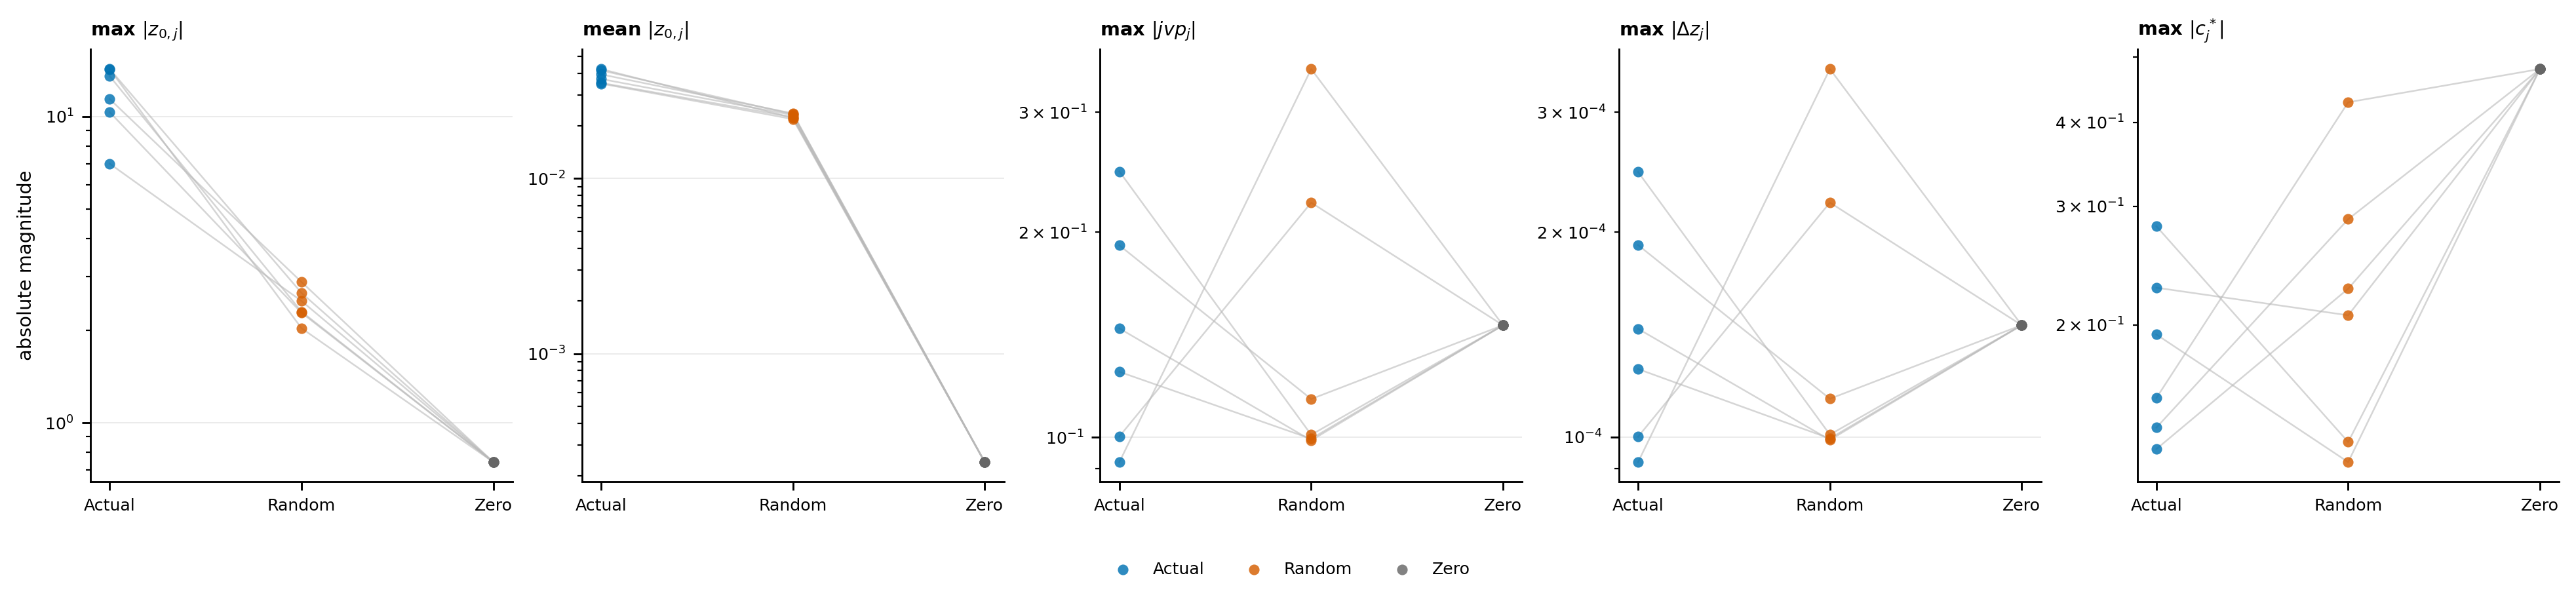

In [8]:
PAPER_BLUE = "#0072B2"
PAPER_ORANGE = "#D55E00"
PAPER_GRAY = "#666666"

condition_order = [condition for condition in ["actual", "random", "zero"] if condition in set(results["embedding_condition"])]
condition_labels = {"actual": "Actual", "random": "Random", "zero": "Zero"}
condition_colors = {"actual": PAPER_BLUE, "random": PAPER_ORANGE, "zero": PAPER_GRAY}
plot_results = results.loc[results["embedding_condition"] == "actual"].copy().reset_index(drop=True)
metric_means = results.groupby("embedding_condition")[metric_cols].mean().reindex(condition_order)

previous_rcparams = plt.rcParams.copy()
plt.rcParams.update({
    "figure.dpi": 260,
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Metric summary for actual explanations and random/zero embedding controls.
fig, ax = plt.subplots(figsize=(7.4, 2.7), constrained_layout=True)
x = np.arange(len(metric_cols))
bar_width = 0.22
condition_offsets = {condition: (index - (len(condition_order) - 1) / 2) * bar_width for index, condition in enumerate(condition_order)}

for condition in condition_order:
    offset = condition_offsets[condition]
    values = metric_means.loc[condition].to_numpy(dtype=float)
    ax.bar(
        x + offset,
        values,
        width=bar_width * 0.9,
        color=condition_colors[condition],
        alpha=0.38,
        label=condition_labels[condition],
        zorder=2,
    )
    condition_rows = results.loc[results["embedding_condition"] == condition]
    for i, metric in enumerate(metric_cols):
        pair_values = condition_rows[metric].to_numpy(dtype=float)
        ax.scatter(
            np.full(len(pair_values), x[i] + offset, dtype=float),
            pair_values,
            s=13,
            color=condition_colors[condition],
            alpha=0.76,
            linewidth=0,
            zorder=3,
        )

ax.axhline(0.5, color=PAPER_GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([metric_labels[metric] for metric in metric_cols])
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("a  Explanation metric summary", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#DDDDDD", linewidth=0.45, alpha=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=len(condition_order))
plt.show()

# SAE geometry controls from the saved feature-rank tables.
completed = plot_results[["pair", "cancer", "target_idx", "target_score"]].drop_duplicates().reset_index(drop=True)
true_indices = completed["target_idx"].astype(int).to_numpy()
rng = np.random.default_rng(int(CONTROL_SEED))
true_X = Xn[true_indices].astype(np.float32)
random_X = rng.normal(loc=0.0, scale=1.0, size=true_X.shape).astype(np.float32)
zero_X = np.zeros_like(true_X, dtype=np.float32)

@torch.no_grad()
def encode_controls(matrix: np.ndarray) -> np.ndarray:
    encoded = []
    for start in range(0, matrix.shape[0], 256):
        batch = torch.from_numpy(matrix[start : start + 256]).to(DEVICE)
        encoded.append(sae.encode(batch).detach().cpu().numpy())
    return np.concatenate(encoded, axis=0)

control_codes = {
    "actual": encode_controls(true_X),
    "random": encode_controls(random_X),
    "zero": encode_controls(zero_X),
}
condition_output_dirs = {
    (row["pair"], row["embedding_condition"]): Path(row["output_dir"])
    for _, row in results.iterrows()
}
geometry_rows = []
for condition in condition_order:
    for row_index, row in completed.iterrows():
        feature_rank = pd.read_csv(condition_output_dirs[(row["pair"], condition)] / "feature_rank.csv")
        z = control_codes[condition][row_index]
        geometry_rows.append({
            "pair": row["pair"],
            "condition": condition,
            "max_abs_z0": float(np.max(np.abs(z))),
            "mean_abs_z0": float(np.mean(np.abs(z))),
            "max_abs_jvp": float(feature_rank["jvp"].abs().max()),
            "max_abs_delta_z": float(feature_rank["delta_z"].abs().max()),
            "max_abs_c_star": float(feature_rank["c_star"].abs().max()),
        })
geometry_controls = pd.DataFrame(geometry_rows)
display(geometry_controls)

signal_specs = [
    ("max_abs_z0", r"max $|z_{0,j}|$"),
    ("mean_abs_z0", r"mean $|z_{0,j}|$"),
    ("max_abs_jvp", r"max $|jvp_j|$"),
    ("max_abs_delta_z", r"max $|\Delta z_j|$"),
    ("max_abs_c_star", r"max $|c^*_j|$"),
]
fig, axes = plt.subplots(1, len(signal_specs), figsize=(15, 3), constrained_layout=True)
for ax, (signal, label) in zip(axes, signal_specs):
    table = geometry_controls.pivot(index="pair", columns="condition", values=signal).loc[completed["pair"]]
    x_pos = np.arange(len(condition_order))
    for _, values in table.iterrows():
        ax.plot(x_pos, values[condition_order].to_numpy(dtype=float), color="#B8B8B8", linewidth=0.7, alpha=0.58, zorder=1)
    for position, condition in enumerate(condition_order):
        ax.scatter(
            np.full(len(table), position, dtype=float),
            table[condition].to_numpy(dtype=float),
            color=condition_colors[condition],
            s=20,
            alpha=0.82,
            linewidth=0,
            label=condition_labels[condition] if signal == "max_abs_z0" else None,
            zorder=2,
        )
    ax.set_yscale("log")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([condition_labels[condition] for condition in condition_order])
    ax.set_title(label, loc="left", fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.45, alpha=0.7)
    ax.set_axisbelow(True)
axes[0].set_ylabel("absolute magnitude")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=len(condition_order))
plt.show()

plt.rcParams.update(previous_rcparams)
